# **UNSW_NB15 Dataset**

Importovanie potrebných knižníc pre prácu s datasetom

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
import sklearn
import sklearn.cluster
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, auc
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier



# **Popis dát**
Odkaz na UNSW_NB15 dataset: [Kaggle](https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15)

---

| Atribút              | Popis                                                                                     |
|:---------------------|:------------------------------------------------------------------------------------------|
| `srcip`              | Zdrojová IP adresa                                                                        |
| `sport`              | Zdrojový port                                                                             |
| `dstip`              | Cieľová IP adresa                                                                         |
| `dsport`             | Cieľový port                                                                              |
| `proto`              | Protokol transakcie (napr. TCP, UDP)                                                      |
| `state`              | Stav spojenia a závislý protokol (napr. ACC, CLO, CON, FIN, URH, atď.)( - ak nepoužité)                    |
| `dur`                | Celkové trvanie spojenia                                                                  |
| `sbytes`             | Počet bajtov odoslaných zo zdroja                                                         |
| `dbytes`             | Počet bajtov prijatých cieľom                                                             |
| `sttl`               | Hodnota TTL (time-to-live) zo zdroja do cieľa                                             |
| `dttl`               | Hodnota TTL (time-to-live) z cieľa do zdroja                                              |
| `sloss`              | Počet stratených alebo opakovaných paketov na strane zdroja                               |
| `dloss`              | Počet stratených alebo opakovaných paketov na strane cieľa                                |
| `service`            | Typ služby (napr. http, ftp, smtp, ssh, dns)                                              |
| `Sload`              | Rýchlosť odosielania (bitov za sekundu)                                                   |
| `Dload`              | Rýchlosť prijímania (bitov za sekundu)                                                    |
| `Spkts`              | Počet paketov odoslaných zo zdroja                                                        |
| `Dpkts`              | Počet paketov prijatých cieľom                                                            |
| `swin`               | Zdrojová TCP veľkosť okna                                                                 |
| `dwin`               | Cieľová TCP veľkosť okna                                                                  |
| `stcpb`              | Počiatočný TCP sekvenčný bajt zdrojovej adresy                                            |
| `dtcpb`              | Počiatočný TCP sekvenčný bajt cieľovej adresy                                             |
| `smeansz`            | Priemerná veľkosť paketov odosielaných zdrojom                                            |
| `dmeansz`            | Priemerná veľkosť paketov odosielaných cieľom                                             |
| `trans_depth`        | Hĺbka transakcie (počet úrovní v HTTP požiadavke/odpovedi)                                |
| `res_bdy_len`        | Skutočná nekomprimovaná veľkosť prenesených dát z HTTP služby                             |
| `Sjit`               | Zdrojový jitter (v ms)                                                                    |
| `Djit`               | Cieľový jitter (v ms)                                                                     |
| `Stime`              | Čas začiatku záznamu                                                                      |
| `Ltime`              | Čas konca záznamu                                                                         |
| `Sintpkt`            | Priemerný čas medzi odoslanými paketmi (v ms)                                             |
| `Dintpkt`            | Priemerný čas medzi prijatými paketmi (v ms)                                              |
| `tcprtt`             | Doba pre cyklus TCP (súčet `synack` a `ackdat`)                                           |
| `synack`             | Čas medzi SYN a SYN_ACK paketmi                                                           |
| `ackdat`             | Čas medzi SYN_ACK a ACK paketmi                                                           |
| `is_sm_ips_ports`    | Hodnota 1, ak sú zdrojové a cieľové IP adresy a porty rovnaké, inak 0                      |
| `ct_state_ttl`       | Počet stavov podľa TTL (zdroj/cieľ)                                                       |
| `ct_flw_http_mthd`   | Počet tokov s HTTP metódami ako GET a POST                                                |
| `is_ftp_login`       | Hodnota 1, ak FTP relácia využíva používateľské meno a heslo, inak 0                       |
| `ct_ftp_cmd`         | Počet tokov s príkazmi v FTP relácii                                                      |
| `ct_srv_src`         | Počet spojení obsahujúcich rovnakú službu a zdrojovú adresu v posledných 100 spojeniach    |
| `ct_srv_dst`         | Počet spojení obsahujúcich rovnakú službu a cieľovú adresu v posledných 100 spojeniach     |
| `ct_dst_ltm`         | Počet spojení k rovnakej cieľovej adrese za posledných 100 spojení                        |
| `ct_src_ltm`         | Počet spojení od rovnakej zdrojovej adresy za posledných 100 spojení                      |
| `ct_src_dport_ltm`   | Počet spojení od rovnakej zdrojovej adresy k rovnakému cieľovému portu za posledných 100   |
| `ct_dst_sport_ltm`   | Počet spojení k rovnakej cieľovej adrese od rovnakého zdrojového portu za posledných 100   |
| `ct_dst_src_ltm`     | Počet spojení medzi rovnakými zdrojovými a cieľovými adresami za posledných 100 spojení    |
| `attack_cat`         | Kategória útoku (napr. Fuzzers, DoS, Reconnaissance)                                      |
| `label`              | Klasifikácia (0 = normálne, 1 = útok)                                                     |





# **Načítanie UNSW_NB15 datasetu**



In [ ]:
df_train = pd.read_csv('UNSW_NB15_training-set.csv')
df_test = pd.read_csv('UNSW_NB15_testing-set.csv')

Dropnutie stĺpcu `attack_cat` a aj nepotrebného stĺpcu `id`

In [ ]:
target_col = 'label'

if 'attack_cat' in df_train.columns:
    df_train.drop('attack_cat', axis=1, inplace=True)
if 'attack_cat' in df_test.columns:
    df_test.drop('attack_cat', axis=1, inplace=True)

drop_cols = ['id']
for c in drop_cols:
    if c in df_train.columns:
        df_train.drop(c, axis=1, inplace=True)
    if c in df_test.columns:
        df_test.drop(c, axis=1, inplace=True)

In [ ]:
df_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,2,1,3,0,0,0,2,3,0,0


In [ ]:
df_test.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,1,1,0,0,0,1,1,0,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,1,2,0,0,0,1,6,0,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,1,3,0,0,0,2,6,0,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,1,3,1,1,0,2,1,0,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,2,1,40,0,0,0,2,39,0,0


**Zistenie dátových typov v datasete a kontrola, či sa tam nenachádzajú NaN hodnoty.**

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dur                82332 non-null  float64
 1   proto              82332 non-null  object 
 2   service            82332 non-null  object 
 3   state              82332 non-null  object 
 4   spkts              82332 non-null  int64  
 5   dpkts              82332 non-null  int64  
 6   sbytes             82332 non-null  int64  
 7   dbytes             82332 non-null  int64  
 8   rate               82332 non-null  float64
 9   sttl               82332 non-null  int64  
 10  dttl               82332 non-null  int64  
 11  sload              82332 non-null  float64
 12  dload              82332 non-null  float64
 13  sloss              82332 non-null  int64  
 14  dloss              82332 non-null  int64  
 15  sinpkt             82332 non-null  float64
 16  dinpkt             823

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                175341 non-null  float64
 1   proto              175341 non-null  object 
 2   service            175341 non-null  object 
 3   state              175341 non-null  object 
 4   spkts              175341 non-null  int64  
 5   dpkts              175341 non-null  int64  
 6   sbytes             175341 non-null  int64  
 7   dbytes             175341 non-null  int64  
 8   rate               175341 non-null  float64
 9   sttl               175341 non-null  int64  
 10  dttl               175341 non-null  int64  
 11  sload              175341 non-null  float64
 12  dload              175341 non-null  float64
 13  sloss              175341 non-null  int64  
 14  dloss              175341 non-null  int64  
 15  sinpkt             175341 non-null  float64
 16  di

In [ ]:
print("\nNaN v df_train:", df_train.isna().sum().sum())
print("NaN v df_test:", df_test.isna().sum().sum())


NaN v df_train: 0
NaN v df_test: 0


Pomocou df.info() sme zistili, že nie všetky atribúty majú číselný typ ale v datasete sa nachádzajú aj kategorické dáta. Taktiež sme zistili, že dataset neobsahuje žiadne hodnoty NaN, takže nie je potrebné ošetriť prázdne hodnoty pred ďalšou analýzou.

In [ ]:
df_train.shape

(82332, 43)

In [ ]:
df_test.shape

(175341, 43)

**Základné štatistické charakteristiky dát v datasete a identifikácia rozsahov hodnôt jednotlivých atribútov.**

Numerické hodnoty:

In [ ]:
df_train.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,6.305470e+05,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,2.393001e+06,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,2.112951e+03,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,1.585808e+04,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,2.082111e+07,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [ ]:
df_train.describe(exclude=np.number)

,proto,service,state
count,82332,82332,82332
unique,131,13,7
top,tcp,-,FIN
freq,43095,47153,39339


# **Vizualizácia dát**

Na základe predošlej analýzy datasetu sme zistili, že nie všetky atribúty spadajú do numerickej kategórie, a tak ich nemôžeme všetky vizualizovať pomocou histogramov ale kategorické musíme osobitne.



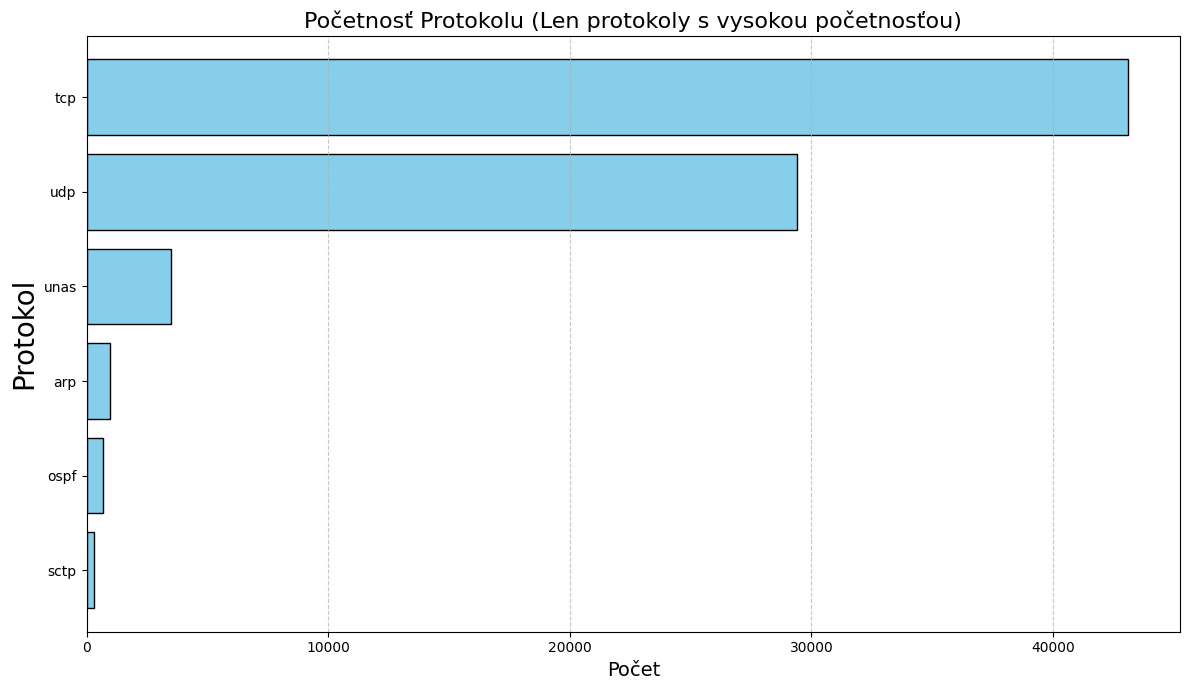

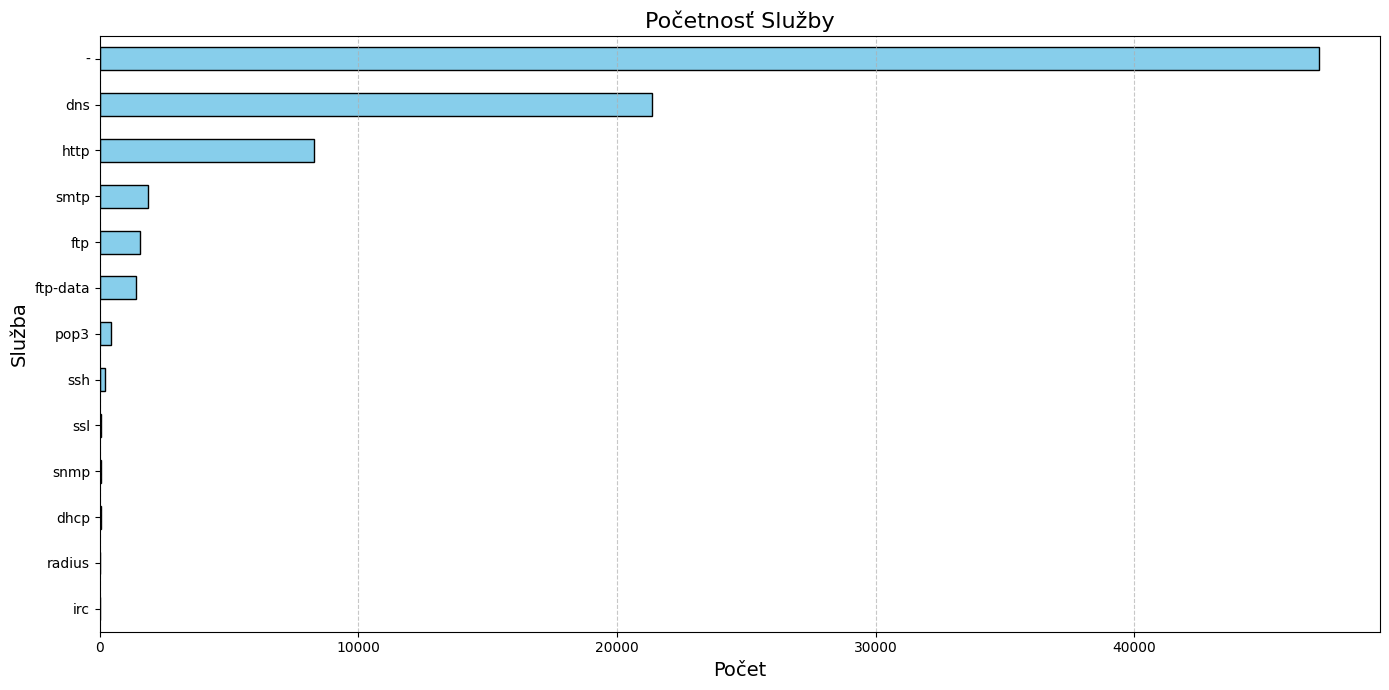

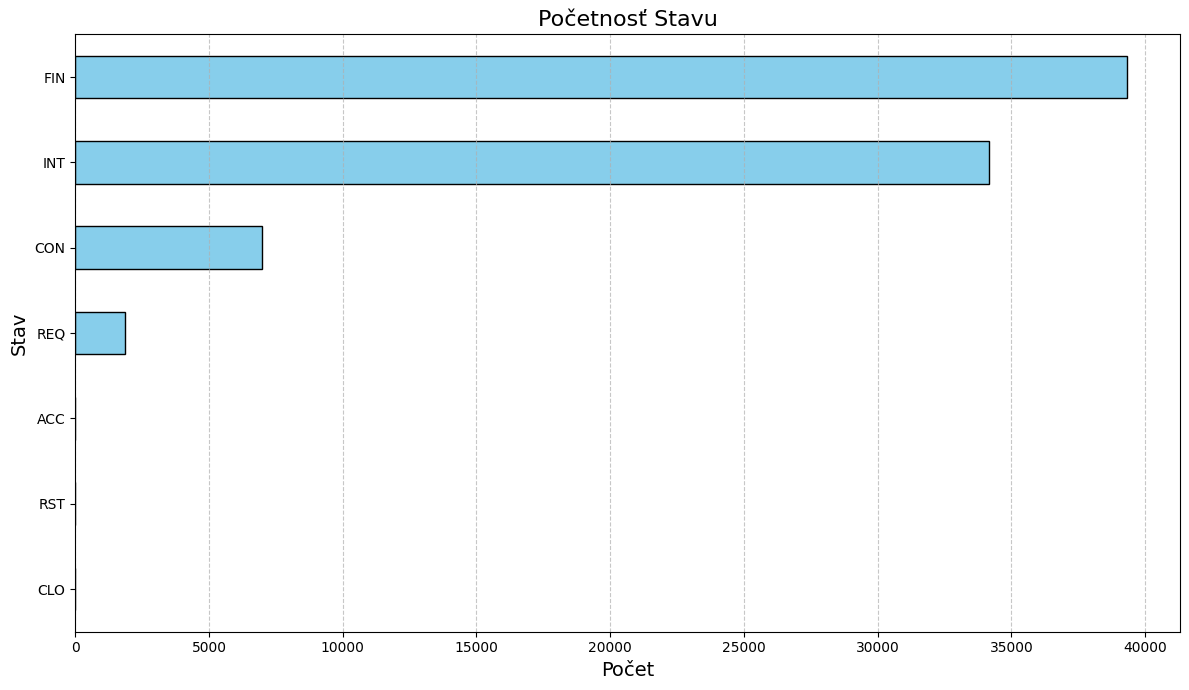

In [ ]:
threshold = 100
proto_counts_filtered = df_train['proto'].value_counts()
proto_counts_filtered = proto_counts_filtered[proto_counts_filtered > threshold].sort_values()

plt.figure(figsize=(12, 7))
proto_counts_filtered.plot(kind='barh', color='skyblue', edgecolor='black', width=0.8)
plt.title('Početnosť Protokolu (Len protokoly s vysokou početnosťou)', fontsize=16)
plt.xlabel('Počet', fontsize=14)
plt.ylabel('Protokol', fontsize=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
df_train['service'].value_counts().sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Početnosť Služby', fontsize=16)
plt.xlabel('Počet', fontsize=14)
plt.ylabel('Služba', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
df_train['state'].value_counts().sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Početnosť Stavu', fontsize=16)
plt.xlabel('Počet', fontsize=14)
plt.ylabel('Stav', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Text(0.5, 0, 'Počet')

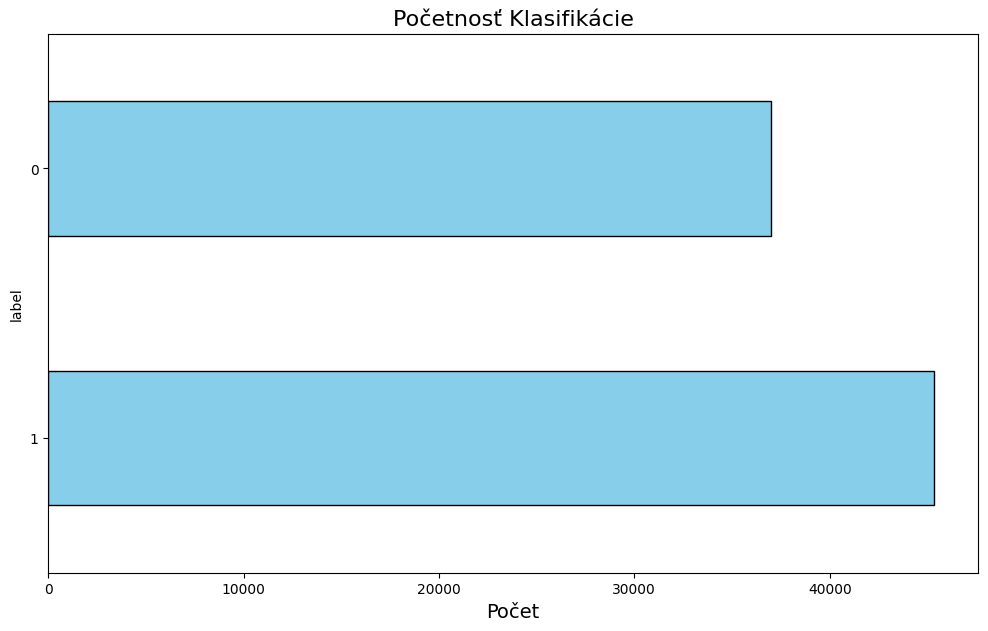

In [ ]:
plt.figure(figsize=(12, 7))
df_train.label.value_counts().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Početnosť Klasifikácie', fontsize=16)
plt.xlabel('Počet', fontsize=14)

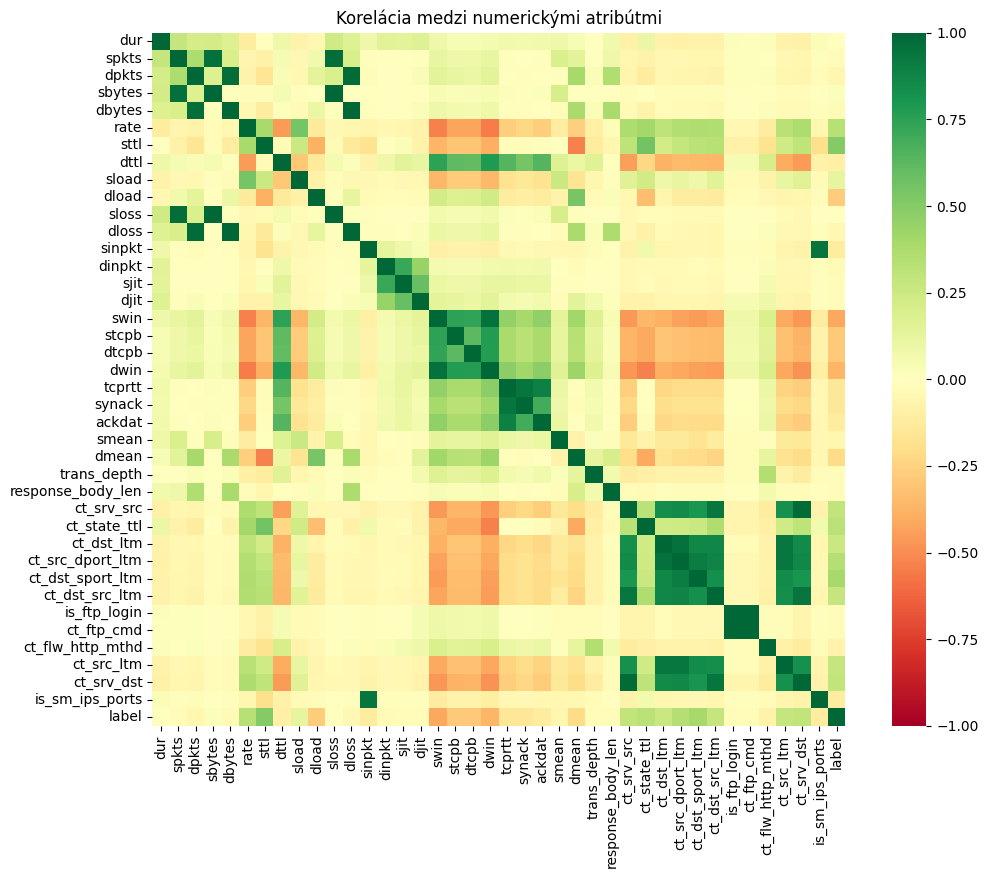

In [ ]:
numerical_features = df_train.select_dtypes(include=np.number)

df_corr = numerical_features.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(df_corr, square=True, cmap='RdYlGn', vmin=-1, vmax=1, annot=False)
plt.title('Korelácia medzi numerickými atribútmi')
plt.show()

# **Preprocessing dát**

Na preprocessing numerických dát sme sa rozhodli použit MinMaxScaler a pre spracovanie kategorických dát OrdinalEncoder.



**Preprocessing kategorických dát**

In [ ]:
proto_categories = sorted(list(set(df_train['proto'].unique()) | set(df_test['proto'].unique())))

enc_proto = OrdinalEncoder(
    categories=[proto_categories],
)

df_train.loc[:, 'proto'] = enc_proto.fit_transform(df_train[['proto']])[:, 0]
df_test.loc[:, 'proto'] = enc_proto.transform(df_test[['proto']])[:, 0]



In [ ]:
service_categories = sorted(list(set(df_train['service'].unique()) | set(df_test['service'].unique())))

enc_service = OrdinalEncoder(
    categories=[service_categories],
)

df_train.loc[:, 'service'] = enc_service.fit_transform(df_train[['service']])[:, 0]
df_test.loc[:, 'service'] = enc_service.transform(df_test[['service']])[:, 0]



In [ ]:
state_categories = sorted(list(set(df_train['state'].unique()) | set(df_test['state'].unique())))

enc_state = OrdinalEncoder(
    categories=[state_categories],
)

df_train.loc[:, 'state'] = enc_state.fit_transform(df_train[['state']])[:, 0]
df_test.loc[:, 'state'] = enc_state.transform(df_test[['state']])[:, 0]



In [ ]:
df_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.000011,119.0,0.0,5.0,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,119.0,0.0,5.0,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,119.0,0.0,5.0,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,119.0,0.0,5.0,2,0,900,0,166666.6608,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,119.0,0.0,5.0,2,0,2126,0,100000.0025,254,...,2,1,3,0,0,0,2,3,0,0


In [ ]:
df_test.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.121478,113.0,0.0,4.0,6,4,258,172,74.087490,252,...,1,1,1,0,0,0,1,1,0,0
1,0.649902,113.0,0.0,4.0,14,38,734,42014,78.473372,62,...,1,1,2,0,0,0,1,6,0,0
2,1.623129,113.0,0.0,4.0,8,16,364,13186,14.170161,62,...,1,1,3,0,0,0,2,6,0,0
3,1.681642,113.0,3.0,4.0,12,12,628,770,13.677108,62,...,1,1,3,1,1,0,2,1,0,0
4,0.449454,113.0,0.0,4.0,10,6,534,268,33.373826,254,...,2,1,40,0,0,0,2,39,0,0


**Preprocessing numerických dát**

In [ ]:
scaler = MinMaxScaler()

train_labels = df_train['label'].values
test_labels  = df_test['label'].values

df_train_nolabel = df_train.drop('label', axis=1)
df_test_nolabel  = df_test.drop('label', axis=1)

df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train_nolabel),
                               columns=df_train_nolabel.columns,
                               index=df_train.index)
df_test_scaled  = pd.DataFrame(scaler.transform(df_test_nolabel),
                               columns=df_test_nolabel.columns,
                               index=df_test.index)

df_train_scaled['label'] = train_labels
df_test_scaled['label']  = test_labels

In [ ]:
df_train_scaled.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,1.833334e-07,0.901515,0.0,0.625,0.000094,0.0,0.000033,0.0,0.090909,0.996078,...,0.000000,0.0,0.016129,0.0,0.0,0.0,0.000000,0.016393,0.0,0
1,1.333334e-07,0.901515,0.0,0.625,0.000094,0.0,0.000121,0.0,0.125000,0.996078,...,0.000000,0.0,0.016129,0.0,0.0,0.0,0.000000,0.016393,0.0,0
2,8.333335e-08,0.901515,0.0,0.625,0.000094,0.0,0.000073,0.0,0.200000,0.996078,...,0.000000,0.0,0.032258,0.0,0.0,0.0,0.000000,0.032787,0.0,0
3,1.000000e-07,0.901515,0.0,0.625,0.000094,0.0,0.000061,0.0,0.166667,0.996078,...,0.017241,0.0,0.032258,0.0,0.0,0.0,0.016949,0.032787,0.0,0
4,1.666667e-07,0.901515,0.0,0.625,0.000094,0.0,0.000146,0.0,0.100000,0.996078,...,0.017241,0.0,0.032258,0.0,0.0,0.0,0.016949,0.032787,0.0,0


In [ ]:
df_test_scaled.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.002025,0.856061,0.00,0.5,0.000470,0.000363,0.000016,0.000012,0.000074,0.988235,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0
1,0.010832,0.856061,0.00,0.5,0.001221,0.003449,0.000049,0.002866,0.000078,0.243137,...,0.000000,0.0,0.016129,0.0,0.0,0.0,0.000000,0.081967,0.0,0
2,0.027052,0.856061,0.00,0.5,0.000658,0.001452,0.000024,0.000900,0.000014,0.243137,...,0.000000,0.0,0.032258,0.0,0.0,0.0,0.016949,0.081967,0.0,0
3,0.028027,0.856061,0.25,0.5,0.001033,0.001089,0.000042,0.000053,0.000014,0.243137,...,0.000000,0.0,0.032258,0.5,0.5,0.0,0.016949,0.000000,0.0,0
4,0.007491,0.856061,0.00,0.5,0.000845,0.000545,0.000036,0.000018,0.000033,0.996078,...,0.017241,0.0,0.629032,0.0,0.0,0.0,0.016949,0.622951,0.0,0


# **Trénovanie modelu**

In [ ]:
X_train = df_train_scaled.drop(target_col, axis=1)
y_train = df_train_scaled[target_col]

X = X_train
y = y_train

X_test = df_test_scaled.drop(target_col, axis=1)
y_test = df_test_scaled[target_col]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(82332, 42) (175341, 42) (82332,) (175341,)


In [ ]:
X_train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,1.833334e-07,0.901515,0.0,0.625,0.000094,0.000000,0.000033,0.000000,0.090909,0.996078,...,0.000000,0.000000,0.0,0.016129,0.0,0.0,0.0,0.000000,0.016393,0.0
1,1.333334e-07,0.901515,0.0,0.625,0.000094,0.000000,0.000121,0.000000,0.125000,0.996078,...,0.000000,0.000000,0.0,0.016129,0.0,0.0,0.0,0.000000,0.016393,0.0
2,8.333335e-08,0.901515,0.0,0.625,0.000094,0.000000,0.000073,0.000000,0.200000,0.996078,...,0.000000,0.000000,0.0,0.032258,0.0,0.0,0.0,0.000000,0.032787,0.0
3,1.000000e-07,0.901515,0.0,0.625,0.000094,0.000000,0.000061,0.000000,0.166667,0.996078,...,0.017241,0.017241,0.0,0.032258,0.0,0.0,0.0,0.016949,0.032787,0.0
4,1.666667e-07,0.901515,0.0,0.625,0.000094,0.000000,0.000146,0.000000,0.100000,0.996078,...,0.017241,0.017241,0.0,0.032258,0.0,0.0,0.0,0.016949,0.032787,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,8.333335e-08,0.901515,0.0,0.625,0.000094,0.000000,0.000006,0.000000,0.200000,0.996078,...,0.017241,0.000000,0.0,0.016129,0.0,0.0,0.0,0.016949,0.000000,0.0
82328,1.843502e-02,0.856061,0.0,0.500,0.001785,0.000726,0.001257,0.000024,0.000024,0.996078,...,0.017241,0.000000,0.0,0.000000,0.0,0.0,0.0,0.033898,0.016393,0.0
82329,0.000000e+00,0.045455,0.0,0.625,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,1.0
82330,0.000000e+00,0.045455,0.0,0.625,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,1.0


In [ ]:
y_train

,label
0,0
1,0
2,0
3,0
4,0
...,...
82327,0
82328,0
82329,0
82330,0


# **Decision Tree Classifier**

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.8956
Precision: 0.9810
Recall: 0.8634
F1 Score: 0.9185


**Testovanie hyper-parametrov**


---


**DecisionTreeClassifier - bez hyper-parametrov**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8807959221273721,
 0.9888479982156797,
 0.9407269948695557,
 0.904985307006238,
 0.9286211512717537]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.92879547469812, 0.8807959221273721, 0.9888479982156797)

**1. experiment - DecisionTreeClassifier - max_depth**

In [ ]:
scores_global = []
for x in np.arange(2,25):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf=DecisionTreeClassifier(max_depth=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.7780391297996065),
 (3, 0.8825154957196244),
 (4, 0.8764723509005226),
 (5, 0.8915983551742539),
 (6, 0.923932700345086),
 (7, 0.9172353818129689),
 (8, 0.9241937136117434),
 (9, 0.9314628805938534),
 (10, 0.9317228611806346),
 (11, 0.9347420146578272)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['max_depth', 'f1'])
df_res.tail()

,max_depth,f1
18,20,0.929302
19,21,0.930872
20,22,0.929717
21,23,0.929510
22,24,0.928177


<Axes: xlabel='max_depth', ylabel='f1'>

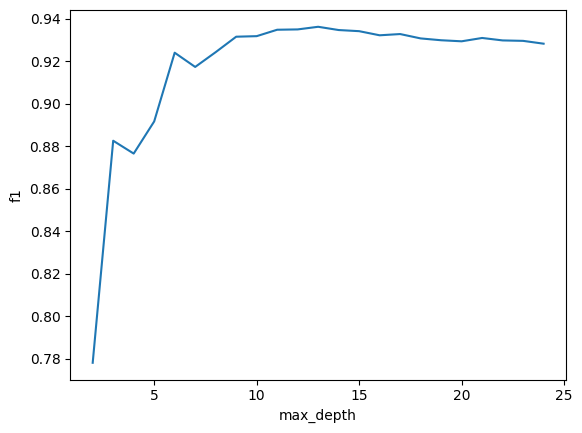

In [ ]:
sns.lineplot(data = df_res, x='max_depth', y='f1')

In [ ]:
df_res.sort_values(by='f1', ascending=False).head(5)

,max_depth,f1
11,13,0.936134
10,12,0.934895
9,11,0.934742
12,14,0.934602
13,15,0.934068


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13, max_depth=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8836410476599399,
 0.9905366288131819,
 0.9477880516029012,
 0.9187513138532689,
 0.9399534354864909]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9361340954831565, 0.8836410476599399, 0.9905366288131819)

**2. experiment - DecisionTreeClassifier - min_samples_split**

In [ ]:
scores_global = []
for x in np.arange(2,25):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf=DecisionTreeClassifier(min_samples_split=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.92879547469812),
 (3, 0.9305990964208227),
 (4, 0.928395794805209),
 (5, 0.9287861278906077),
 (6, 0.9305098742442718),
 (7, 0.9301631339062197),
 (8, 0.9290885721927025),
 (9, 0.9303972562255554),
 (10, 0.9300637548546666),
 (11, 0.9304419198939273)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['min_samples_split', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,min_samples_split,f1
15,17,0.931079
19,21,0.931060
12,14,0.930834
1,3,0.930599
4,6,0.930510


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13, min_samples_split=17)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8820462491565969,
 0.9878885974214433,
 0.9424129625574775,
 0.9098132287689609,
 0.9332326609858699]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9310787397780697, 0.8820462491565969, 0.9878885974214433)

**3. experiment - DecisionTreeClassifier - max_depth(const) + min_samples_split**

In [ ]:
scores_global = []
for x in np.arange(2,25):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf=DecisionTreeClassifier(max_depth=13,min_samples_split=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.9361340954831565),
 (3, 0.9328266876669684),
 (4, 0.9338947178355254),
 (5, 0.9329982026797273),
 (6, 0.9322953232543181),
 (7, 0.9352094972794651),
 (8, 0.9328925561143722),
 (9, 0.932879670508626),
 (10, 0.932776511058667),
 (11, 0.9340205199367846)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['min_samples_split', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,min_samples_split,f1
0,2,0.936134
11,13,0.935708
12,14,0.935437
5,7,0.935209
16,18,0.934481


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13, min_samples_split=5, max_depth=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8755173904985483,
 0.9912666184569172,
 0.9429105708942911,
 0.917927700714586,
 0.9373687328342937]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9329982026797273, 0.8755173904985483, 0.9912666184569172)

**4. experiment - DecisionTreeClassifier - max_depth + min_samples_split(const)**

In [ ]:
scores_global = []
for x in np.arange(2,25):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf=DecisionTreeClassifier(max_depth=x,min_samples_split=5,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.7780391297996065),
 (3, 0.8825154957196244),
 (4, 0.8764723509005226),
 (5, 0.8915983551742539),
 (6, 0.923932700345086),
 (7, 0.9172550779136801),
 (8, 0.924321658524525),
 (9, 0.9315557469628508),
 (10, 0.9313659492505583),
 (11, 0.9357561874887933)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['max_depth', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,max_depth,f1
12,14,0.936921
10,12,0.935931
9,11,0.935756
15,17,0.934638
14,16,0.933840


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13, min_samples_split=24, max_depth=12)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8732359494924486,
 0.9870971345584539,
 0.9434252444249148,
 0.9226551378710391,
 0.9420970266040689]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9337020985901852, 0.8732359494924486, 0.9870971345584539)

**5. experiment - DecisionTreeClassifier - splitter**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13, splitter="random")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9072288435048212,
 0.9856239861274263,
 0.9461071231363888,
 0.9111786210802739,
 0.9293079621558414]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9358893072009504, 0.9072288435048212, 0.9856239861274263)

# KNeighborsClassifier
**KNeighborsClassifier - bez hyper-parametrov**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = KNeighborsClassifier()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8096890343698855,
 0.9739730677831844,
 0.9190160620015725,
 0.8814262905800958,
 0.9062275515278776]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.8980664012525231, 0.8096890343698855, 0.9739730677831844)

**6. experiment - KNeighborsClassifier - n_neighbors**

In [ ]:
scores_global = []
for x in np.arange(2,10):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf = KNeighborsClassifier(n_neighbors=x)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.8910366148495836),
 (3, 0.8998233101707906),
 (4, 0.8916534435864509),
 (5, 0.8980664012525231),
 (6, 0.8935451886154724),
 (7, 0.8987186024641771),
 (8, 0.8942759146191077),
 (9, 0.899528918883196)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['n_neighbors', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,n_neighbors,f1
1,3,0.899823
7,9,0.899529
5,7,0.898719
3,5,0.898066
6,8,0.894276


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8250808015513897,
 0.9747272007689264,
 0.915176575771122,
 0.8798556569730418,
 0.9042763157894737]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.8998233101707906, 0.8250808015513897, 0.9747272007689264)

**7. experiment - KNeighborsClassifier - weights**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = KNeighborsClassifier(weights="distance")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.818022235225278,
 0.9746112524738479,
 0.9195350665393902,
 0.8831942155351161,
 0.9072426937738246]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9005210927094913, 0.818022235225278, 0.9746112524738479)

**8. experiment - KNeighborsClassifier - leaf_size**

In [ ]:
scores_global = []
for x in np.arange(10,50,10):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf = KNeighborsClassifier(leaf_size=x)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(10, 0.8980664012525231),
 (20, 0.8980664012525231),
 (30, 0.8980664012525231),
 (40, 0.8980664012525231)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['leaf_size', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,leaf_size,f1
0,10,0.898066
1,20,0.898066
2,30,0.898066
3,40,0.898066


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = KNeighborsClassifier(leaf_size=10)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8096890343698855,
 0.9739730677831844,
 0.9190160620015725,
 0.8814262905800958,
 0.9062275515278776]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.8980664012525231, 0.8096890343698855, 0.9739730677831844)

**9. experiment - KNeighborsClassifier - n_neighbors + weights + leaf_size**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = KNeighborsClassifier(n_neighbors=3,weights="distance",leaf_size=10)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.8267269205939316,
 0.9749590187100786,
 0.9158565202815957,
 0.88011882028432,
 0.9046393164265761]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9004601192593004, 0.8267269205939316, 0.9749590187100786)

# AdaBoostClassifier
**AdaBoostClassifier - bez hyper-parametrov**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = AdaBoostClassifier(random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.88344831796813,
 0.9878885974214433,
 0.9135816173613809,
 0.8792640066156708,
 0.9170201196302338]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9162405317993718, 0.8792640066156708, 0.9878885974214433)

**10. expermient - AdaBoostClassifier - n_estimators**

In [ ]:
scores_global = []
for x in np.arange(1,100,10):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf = AdaBoostClassifier(n_estimators=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(1, 0.6686445769995792),
 (11, 0.8799867505829407),
 (21, 0.8874780314467495),
 (31, 0.878636917113995),
 (41, 0.8994913325502889),
 (51, 0.9032918659312112),
 (61, 0.9168625074331513),
 (71, 0.9178146294113796),
 (81, 0.9206812728569709),
 (91, 0.9264477897990029)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['n_estimators', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,n_estimators,f1
9,91,0.926448
8,81,0.920681
7,71,0.917815
6,61,0.916863
5,51,0.903292


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = AdaBoostClassifier(n_estimators=91,random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9105895000895897,
 0.9898618538324421,
 0.9280623608017817,
 0.8846516500785752,
 0.9190735841926254]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9264477897990029, 0.8846516500785752, 0.9898618538324421)

**11. experiment - AdaBoostClassifier - learning_rate**


In [ ]:
scores_global = []
for x in np.arange(2,10):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf = AdaBoostClassifier(learning_rate=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.7538078386911753),
 (3, 0.687560187901657),
 (4, 0.5799640369334349),
 (5, 0.7054949686931179),
 (6, 0.6686445769995792),
 (7, 0.6686445769995792),
 (8, 0.6686445769995792),
 (9, 0.6686445769995792)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['learning_rate', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,learning_rate,f1
0,2,0.753808
3,5,0.705495
1,3,0.687560
4,6,0.668645
5,7,0.668645


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = AdaBoostClassifier(learning_rate=2,random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9854899190261399,
 0.9937295377615005,
 0.7168856721242358,
 0.6358639132372604,
 0.43707015130674004]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.7538078386911753, 0.43707015130674004, 0.9937295377615005)

**12. experiment - AdaBoostClassifier - n_estimators(const) +  learning_rate**


In [ ]:
scores_global = []
for x in np.arange(1,10):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf = AdaBoostClassifier(n_estimators=91,learning_rate=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(1, 0.9264477897990029),
 (2, 0.6688964920822916),
 (3, 0.7682692745901749),
 (4, 0.823955197526488),
 (5, 0.7054949686931179),
 (6, 0.6686445769995792),
 (7, 0.6686445769995792),
 (8, 0.6686445769995792),
 (9, 0.6686445769995792)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['learning_rate', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,learning_rate,f1
0,1,0.926448
3,4,0.823955
2,3,0.768269
4,5,0.705495
1,2,0.668896


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = AdaBoostClassifier(learning_rate=1,n_estimators=91,random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9105895000895897,
 0.9898618538324421,
 0.9280623608017817,
 0.8846516500785752,
 0.9190735841926254]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9264477897990029, 0.8846516500785752, 0.9898618538324421)

# RandomForestClassifier
**RandomForestClassifier - bez hyper-parametrov**

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = RandomForestClassifier(random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9233954451345756,
 0.9928912584693991,
 0.9626302949656244,
 0.9438214247570224,
 0.9628090133450011]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9571094873343245, 0.9233954451345756, 0.9928912584693991)

**13. experiment - RandomForestClassifier - n_estimators**


In [ ]:
scores_global = []
for x in np.arange(1,100,10):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf = RandomForestClassifier(n_estimators=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(1, 0.9331724814652673),
 (11, 0.9534718152896777),
 (21, 0.9539281072047929),
 (31, 0.9561364662777748),
 (41, 0.9563617156039441),
 (51, 0.9574622109314422),
 (61, 0.9559192670117109),
 (71, 0.9559038257851495),
 (81, 0.9564346491391973),
 (91, 0.9562286080297545)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['n_estimators', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,n_estimators,f1
5,51,0.957462
8,81,0.956435
4,41,0.956362
9,91,0.956229
3,31,0.956136


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = RandomForestClassifier(n_estimators=51,random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9291134772633685,
 0.9927234349830584,
 0.9611456483126111,
 0.9421055439944507,
 0.9622229501037232]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9574622109314422, 0.9291134772633685, 0.9927234349830584)

**14. experiment - RandomForestClassifier - max_depth**


In [ ]:
scores_global = []
for x in np.arange(2,25):
  skf = StratifiedKFold(n_splits=5)
  scores=[]
  for train_index,test_index in skf.split(X,y):
      X_train,X_test=X.iloc[train_index,:],X.iloc[test_index,:]
      y_train,y_test=y.iloc[train_index],y.iloc[test_index]
      clf=RandomForestClassifier(max_depth=x,random_state=13)
      clf.fit(X_train,y_train)
      y_pred=clf.predict(X_test)
      scores.append(f1_score(y_test,y_pred))
  scores_global.append((x,np.mean(scores)))

scores_global[:10]

[(2, 0.8247057850152822),
 (3, 0.8891204707235383),
 (4, 0.9096866397117601),
 (5, 0.9208839947678777),
 (6, 0.930830024168843),
 (7, 0.9357151503787486),
 (8, 0.9388546985584949),
 (9, 0.9425874224655386),
 (10, 0.9439446227789301),
 (11, 0.948106642352023)]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['max_depth', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

,max_depth,f1
19,21,0.959478
17,19,0.958979
16,18,0.958898
21,23,0.958725
20,22,0.958262


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = RandomForestClassifier(max_depth=22,random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9301040503203809,
 0.9932267377304019,
 0.9618608782545939,
 0.9439461883408071,
 0.9621722231346144]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9582620155561598, 0.9301040503203809, 0.9932267377304019)

**15. experiment - RandomForestClassifier - n_estimators + max_depth**


In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = RandomForestClassifier(n_estimators=91,max_depth=22,random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

scores

[0.9277172312223858,
 0.9932267377304019,
 0.9624736316198512,
 0.944064901793339,
 0.9626183569591156]

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

(0.9580201718650188, 0.9277172312223858, 0.9932267377304019)

# **Zhodnotenie**

| Názov algoritmu        | Hyperparameter                                | Výsledné skóre |
|:-----------------------|:---------------------------------------------|:---------------|
| DecisionTreeClassifier | Bez hyperparametrov                         | 0.9287         |
| DecisionTreeClassifier | max_depth = 13                              | 0.9361         |
| DecisionTreeClassifier | min_samples_split = 17                      | 0.9310         |
| DecisionTreeClassifier | max_depth = 13, min_samples_split = 5       | 0.9329         |
| DecisionTreeClassifier | max_depth = 12, min_samples_split = 24       | 0.9337         |
| DecisionTreeClassifier | splitter = "random"                         | 0.9358         |
| KNeighborsClassifier   | Bez hyperparametrov                         | 0.8980         |
| KNeighborsClassifier   | n_neighbors = 3                             | 0.8998         |
| KNeighborsClassifier   | weights = "distance"                        | 0.9005         |
| KNeighborsClassifier   | leaf_size = 10                              | 0.8980         |
| KNeighborsClassifier   | n_neighbors = 3, weights = "distance", leaf_size = 10 | 0.9004 |
| AdaBoostClassifier     | Bez hyperparametrov                         | 0.9162         |
| AdaBoostClassifier     | n_estimators = 91                           | 0.9264         |
| AdaBoostClassifier     | learning_rate = 2                           | 0.7538         |
| AdaBoostClassifier     | learning_rate = 1, n_estimators = 91                           | 0.9264        |
| RandomForestClassifier |bez hyper-parametrov           | 0.9571         |
RandomForestClassifier |n_estimators = 51          | 0.9574         |
RandomForestClassifier |max_depth = 21            | 0.9582        |
RandomForestClassifier |n_estimators = 91, max_depth = 22          | 0.9580         |


Na základe tabuľky možno vidieť, že nastavenie hyperparametrov významne ovplyvňuje výkon jednotlivých modelov. Nižšie popisujem, ako tieto parametre ovplyvnili výsledné skóre.


**DecisionTreeClassifier**

Pri klasifikátore rozhodovacích stromov má nastavenie hĺbky stromu (max_depth) veľký vplyv na presnosť. Zvýšením hĺbky na 13 sa skóre zlepšilo na 0.9361, čo znamená, že model bol schopný lepšie zachytiť štruktúru dát. Ďalej, zvýšenie hodnoty parametra min_samples_split na 24 prinieslo skóre 0.9337, čo naznačuje, že model sa stal robustnejším voči pretrénovaniu. Parameter splitter = "random" mierne zlepšil skóre na 0.9358, pravdepodobne vďaka náhodnému deleniu dát.


**KNeighborsClassifier**

Pri tomto klasifikátore sa ukázalo, že počet susedov (n_neighbors) a váhy (weights) majú na presnosť iba mierny vplyv. Zvýšením počtu susedov na 3 sa skóre zlepšilo na 0.8998. Použitím váženého výpočtu vzdialeností (weights = "distance") sa skóre ešte mierne zvýšilo na 0.9005. Kombinácia viacerých parametrov však nepriniesla výraznejšie zlepšenie, čo naznačuje, že tento klasifikátor je menej citlivý na drobné zmeny nastavení.


**AdaBoostClassifier**

Pri AdaBoost klasifikátore je z tabuľky zrejmé, že parameter n_estimators, ktorý určuje počet slabých klasifikátorov, významne zlepšuje presnosť. Zvýšenie hodnoty na 91 zvýšilo skóre na 0.9264. Naopak, príliš vysoká hodnota parametra learning_rate (napr. 2) znížila výkon na 0.7538, čo ukazuje, že model je citlivý na príliš agresívne učenie. Kombinácia optimálnych hodnôt týchto parametrov priniesla najlepšie výsledky na úrovni 0.9264.


**RandomForestClassifier**

Random Forest dosahoval najvyššiu presnosť zo všetkých testovaných modelov. Nastavenie maximálnej hĺbky stromov (max_depth) na 21 zlepšilo skóre na 0.9582, čo dokazuje, že model je schopný lepšie zachytiť komplexnejšie vzory v dátach. Zmena počtu stromov (n_estimators) na 51 alebo 91 však mala len minimálny dopad, keďže skóre sa pohybovalo v intervale 0.9574 až 0.9580, čo naznačuje, že model je robustný už pri základných nastaveniach.


# **Záver**

Na základe výsledkov je jasné, že optimalizácia hyperparametrov môže mať výrazný vplyv na presnosť modelov. Zatiaľ čo modely ako RandomForestClassifier sú menej citlivé na zmeny parametrov, iné, ako napríklad AdaBoostClassifier, vykazujú väčšie rozdiely v závislosti od nastavenia. Preto je dôležité testovať rôzne kombinácie parametrov, aby sa dosiahol čo najlepší výkon modelu.